In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pathlib
import logging 
from tqdm.auto import tqdm
import time
from typing import Dict
from prettytable import PrettyTable
from copy import deepcopy
import cv2

import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50
from torch.optim import Adam, lr_scheduler
import torchvision.transforms as tfms
import torchvision.transforms.functional as F

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import roc_auc_score

c:\Users\timot\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\timot\anaconda3\envs\torch\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
class CFG:
    CLASS_NAMES =[
        "Atelectasis",
        "Cardiomegaly",
        "Effusion",
        "Infiltration",
        "Mass",
        "Nodule",
        "Pneumonia",
        "Pneumothorax",
        "Consolidation",
        "Edema",
        "Emphysema",
        "Fibrosis",
        "Pleural_Thickening",
    ]
    EPOCHS = 10
    BEST_MODEL_PATH = "models/best_model.pt"
    BASE_PATH = pathlib.Path('./archive (14)')
    DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    INTERVAL = 10

In [3]:
CFG.DEVICE

device(type='cuda')

# Plot Images

In [4]:
df = pd.read_csv("./final_final.csv")

In [5]:
def plot_images(df, rows, columns, figsize=(20, 20)):
    """
    Function to plot images
    """
    fig, axs = plt.subplots(rows, columns, figsize=figsize)
    idx = 0
    for i in range(rows):
        for j in range(columns):
            image = np.asarray(Image.open(df["Image Index"].values[idx]).convert("RGB"))
            # labels = df["Finding Labels"].values[idx].split("|")
            axs[i, j].imshow(image)
            axs[i, j].yaxis.set_visible(False)
            axs[i, j].set_xticklabels([])
            # axs[i, j].set_xlabel(labels)
            idx += 1
    plt.show()

In [6]:
df.head()

,Image Index,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,archive (14)\images-224\images-224\\00019182_0...,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,archive (14)\images-224\images-224\\00009325_0...,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,archive (14)\images-224\images-224\\00029052_0...,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,archive (14)\images-224\images-224\\00011896_0...,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,archive (14)\images-224\images-224\\00018187_0...,1,0,0,0,0,0,0,0,0,0,0,0,0,0


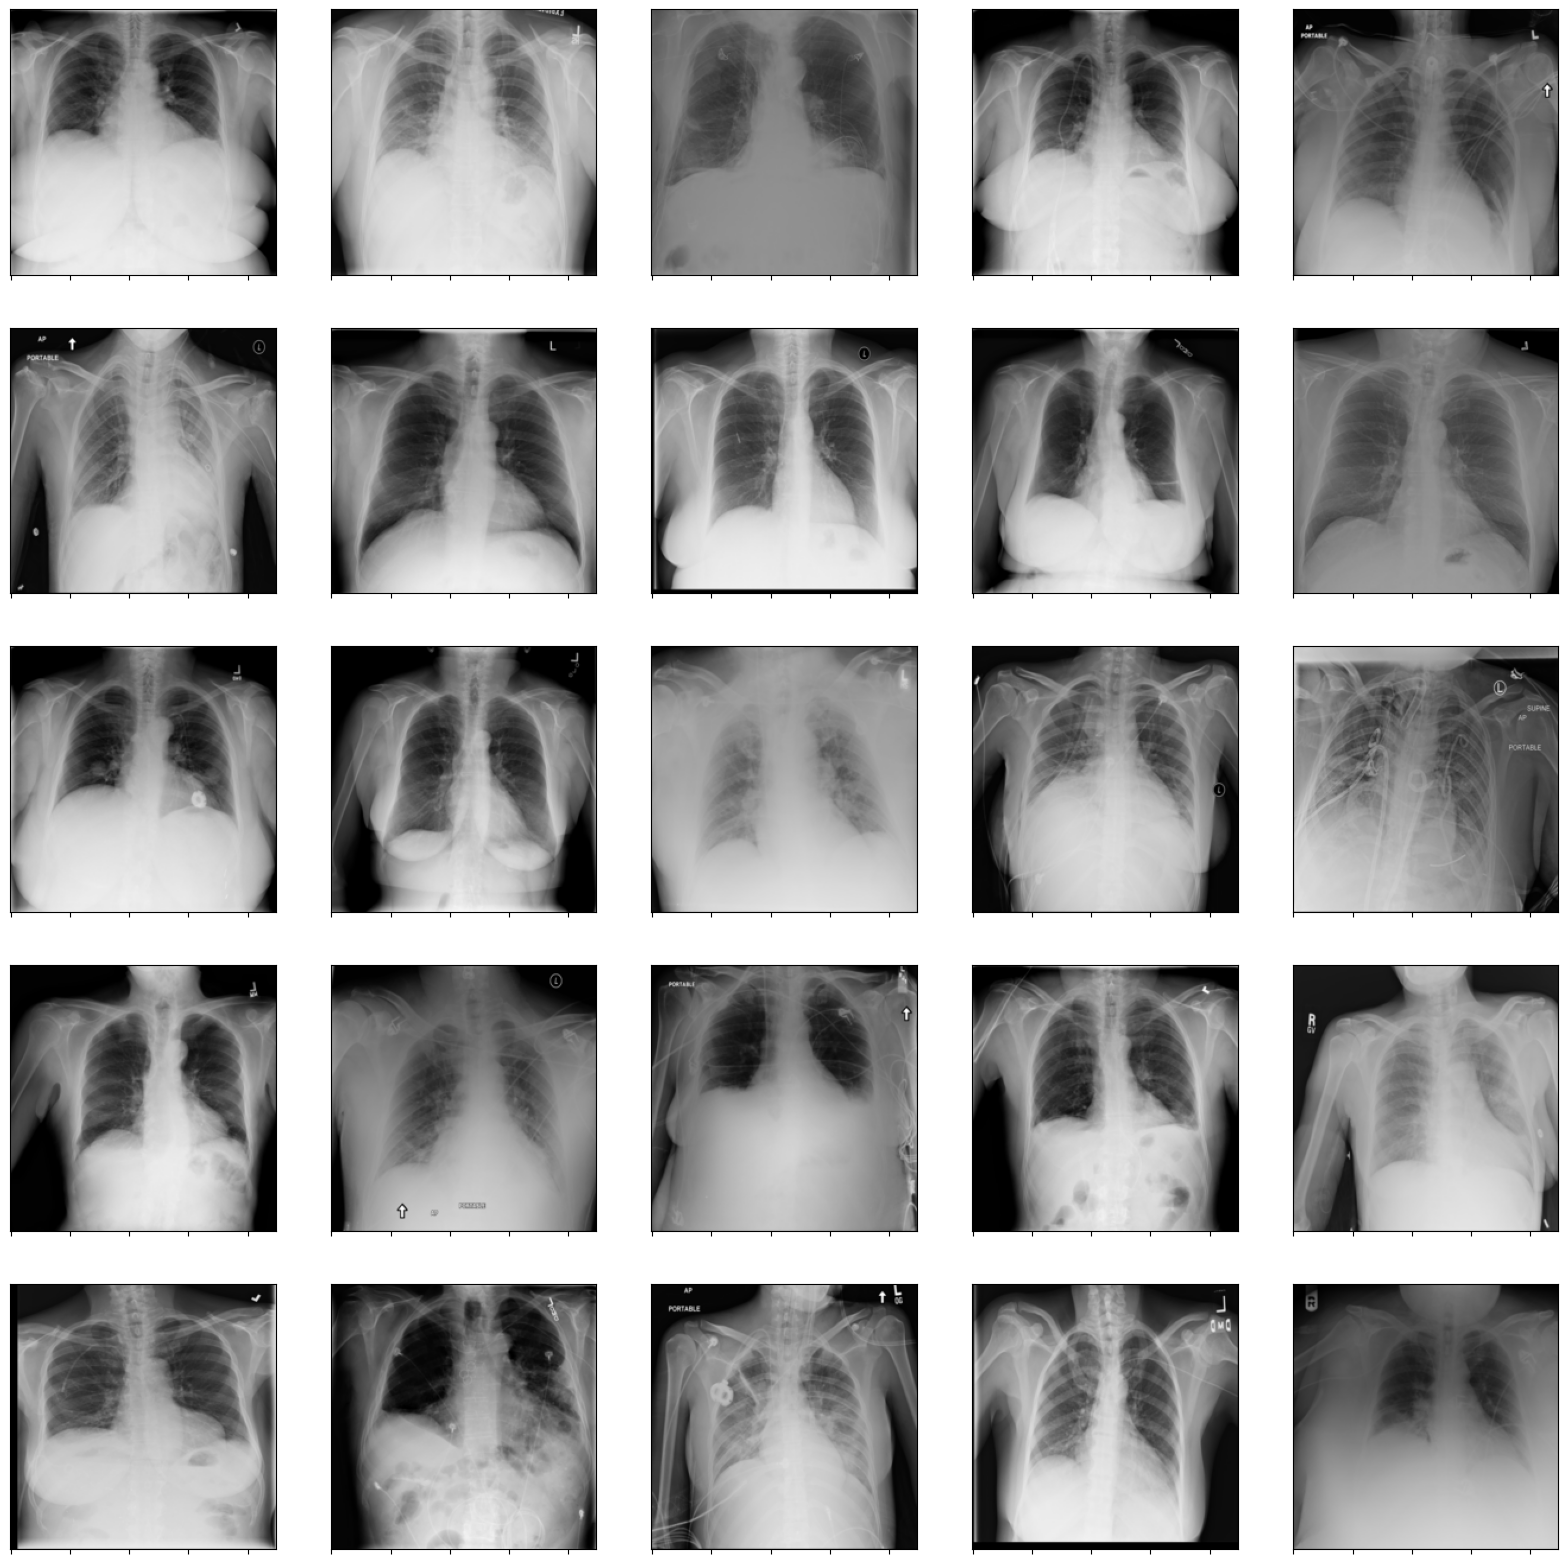

In [7]:
plot_images(df, 5, 5)

In [8]:
class CheXNetData(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transfrom = transform
        
    def __getitem__(self, index):
        image = Image.open(self.df['Image Index'].values[index]).convert("RGB")
        label = self.df.iloc[:, 2:].values[index]
        
        if self.transfrom:
            image = self.transfrom(image=np.array(image))["image"]
            
        label = torch.tensor(label, dtype=torch.float)
        
        return image, label
    
    def __len__(self):
        return len(df)
            

In [9]:
transforms = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  
    ToTensorV2()
])

In [10]:
ds = CheXNetData(df=df, transform=transforms)

In [11]:
image, label = ds[0]

In [12]:
image.size(), label.size()

(torch.Size([3, 224, 224]), torch.Size([13]))

# Train, Val, Test

In [13]:
total = len(ds)
train_len = int(0.8 * total)
val_len = total - train_len

train_ds, test_ds = random_split(dataset=ds, lengths=[train_len, val_len])

In [14]:
total = len(train_ds)
train_len = int(0.8 * total)
val_len = total - train_len

train_ds, val_ds = random_split(dataset=train_ds, lengths=[train_len, val_len])

In [15]:
print(f"The lengths of train, val and test dataset: {len(train_ds)} images, {len(val_ds)} images, and {len(test_ds)} images")

The lengths of train, val and test dataset: 12821 images, 3206 images, and 4007 images


In [16]:
ds_size = {
    "train": len(train_ds), "val": len(val_ds), "test": len(test_ds)
}

In [17]:
ds_size

{'train': 12821, 'val': 3206, 'test': 4007}

# Loaders

In [18]:
loaders = {
    "train": DataLoader(train_ds, batch_size=64, shuffle=True),
    "val": DataLoader(val_ds, batch_size=32),
    "test": DataLoader(test_ds, batch_size=32)
}

In [19]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x20a3af493d0>,
 'val': <torch.utils.data.dataloader.DataLoader at 0x20a3ae5dcd0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x20a38dd3610>}

# Models

In [20]:
class ResNet50(nn.Module):
    def __init__(self, n_classes):
        super(ResNet50, self).__init__()
        
        self.resnet50 = resnet50(pretrained=True)

        n_features = self.resnet50.fc.in_features

        self.resnet50.fc = nn.Sequential(
            nn.Linear(n_features, n_classes),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.resnet50(x)
        return x

In [21]:
ds_batches = {k: len(v) for k, v in loaders.items()}
ds_batches

{'train': 201, 'val': 101, 'test': 126}

In [22]:
pathlib.Path("models").mkdir(exist_ok=True)

logging.basicConfig(
    filename="train.log",
    format= "%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO,
    filemode="w",
)

In [23]:
def calc_mean_auc(labels:torch.tensor, preds: torch.tensor):
    labels = labels.cpu().detach().numpy()
    preds = preds.cpu().detach().numpy()
    
    per_class_AUROC = []
    for i, name in enumerate(CFG.CLASS_NAMES):
        try:
            per_class_AUROC.append(roc_auc_score(labels[:, i], preds[:, i]))
        except ValueError:
            pass
    mean_roc_auc = np.array(per_class_AUROC).mean()
    
    return mean_roc_auc

In [24]:
best_AUROC = 0.0

def run_one_epoch(
    epoch: int,
    ds_sizes: Dict[str, int],
    dataloaders: Dict[str, DataLoader],
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss: nn.Module,
    scheduler: torch.optim.lr_scheduler
):
    """
    Run one complete train-val loop

    Parameter
    ---------

    ds_sizes: Dictionary containing dataset sizes
    dataloaders: Dictionary containing dataloaders
    model: The model
    optimizer: The optimizer
    loss: The loss

    Returns
    -------

    metrics: Dictionary containing metrics

    """
    global best_AUROC
    
    metrics = {}
    AUROCs = []
    
    for phase in ["train", "val"]:
        logging.info(f"{phase.upper()} phase")

        if phase == "train":
            model.train()
        else:
            model.eval()
        
        avg_loss = 0
        running_corrects = 0

        for batch_idx, (images, labels) in enumerate(
            tqdm(dataloaders[phase], total=len(dataloaders[phase]))
        ):

            images = images.to(CFG.DEVICE)
            labels = labels.to(CFG.DEVICE)

            # Zero the gradients
            optimizer.zero_grad()

            # Track history if in phase == "train"
            with torch.set_grad_enabled(phase == "train"):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                if phase == "train":
                    loss.backward()
                    optimizer.step()
                
                # Calculate AUROC
                auroc = calc_mean_auc(labels, outputs)
                AUROCs.append(auroc)

            avg_loss += loss.item() * images.size(0)

            if batch_idx % CFG.INTERVAL == 0:
                logging.info(
                    f"Epoch {epoch} - {phase.upper()} - Batch {batch_idx} - Loss = {round(loss.item(), 3)} | AUROC = {round(auroc, 3)}"
                )

        epoch_loss = avg_loss / ds_sizes[phase]
        epoch_val_mean = np.array(AUROCs).mean()
        
        # step the scheduler
        if phase == "train":
            scheduler.step(epoch_loss)
        
        # save best model wts
        if phase == "val" and epoch_val_mean > best_AUROC:
            best_AUROC = epoch_val_mean
            best_model_wts = deepcopy(model.state_dict())
            timestampTime = time.strftime("%H%M%S")
            timestampDate = time.strftime("%d%m%Y")
            timestampEND = timestampDate + '-' + timestampTime
            best_model_path = f"models/CheXNet-{timestampEND}.pt"
            torch.save({
                "epoch" : epoch, "val_loss": epoch_loss, "val_AUROC": epoch_val_mean, "model": best_model_wts
            }, best_model_path)

        # Metrics tracking
        if phase == "train":
            metrics["train_loss"] = round(epoch_loss, 3)
        else:
            metrics["val_loss"] = round(epoch_loss, 3)
            metrics["val_mean_AUROC"] = round(epoch_val_mean, 3)

    return metrics

In [25]:
def train(dataloaders, ds_sizes, model, optimizer, criterion, scheduler):
    table = PrettyTable(
        field_names=["Epoch", "Train Loss", "Val Loss", "Val Mean AUROC"]
    )
    
    for epoch in range(CFG.EPOCHS):

        start = time.time()

        metrics = run_one_epoch(
            epoch=epoch,
            ds_sizes=ds_sizes,
            dataloaders=dataloaders,
            model=model,
            optimizer=optimizer,
            loss=criterion,
            scheduler=scheduler
        )

        end = time.time() - start

        print(f"Epoch completed in: {round(end/60, 3)} mins")

        table.add_row(
            row=[
                epoch + 1,
                metrics["train_loss"],
                metrics["val_loss"],
                metrics["val_mean_AUROC"]
            ]
        )
        print(table)

    # Write results to file
    with open("results.txt", "w") as f:
        results = table.get_string()
        f.write(results)

In [26]:
model = ResNet50(n_classes=13).to(CFG.DEVICE)
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, mode='min', patience=1)

c:\Users\timot\anaconda3\envs\torch\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\timot\anaconda3\envs\torch\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
params_to_update = []
for name, param in model.named_parameters():
    if "fc" in name:  
        params_to_update.append(param)
        param.requires_grad = True  
    else:
        param.requires_grad = False

In [28]:
train(
    dataloaders=loaders, 
    ds_sizes=ds_size, 
    model=model, 
    optimizer=optimizer, 
    criterion=criterion, 
    scheduler=scheduler
)

100%|██████████| 101/101 [00:07<00:00, 12.67it/s]


Epoch completed in: 0.714 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.264    |  0.252   |     0.613      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.81it/s]


Epoch completed in: 0.698 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.264    |  0.252   |     0.613      |
|   2   |   0.248    |  0.248   |     0.671      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.83it/s]


...

Epoch completed in: 0.693 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.264    |  0.252   |     0.613      |
|   2   |   0.248    |  0.248   |     0.671      |
|   3   |   0.244    |  0.248   |     0.689      |
|   4   |   0.242    |  0.251   |      0.7       |
|   5   |   0.241    |  0.251   |     0.704      |
|   6   |   0.239    |  0.247   |     0.709      |
|   7   |   0.238    |   0.25   |     0.712      |
|   8   |   0.237    |   0.25   |     0.716      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.93it/s]


Epoch completed in: 0.694 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.264    |  0.252   |     0.613      |
|   2   |   0.248    |  0.248   |     0.671      |
|   3   |   0.244    |  0.248   |     0.689      |
|   4   |   0.242    |  0.251   |      0.7       |
|   5   |   0.241    |  0.251   |     0.704      |
|   6   |   0.239    |  0.247   |     0.709      |
|   7   |   0.238    |   0.25   |     0.712      |
|   8   |   0.237    |   0.25   |     0.716      |
|   9   |   0.235    |  0.246   |     0.717      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.83it/s]


Epoch completed in: 0.689 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.264    |  0.252   |     0.613      |
|   2   |   0.248    |  0.248   |     0.671      |
|   3   |   0.244    |  0.248   |     0.689      |
|   4   |   0.242    |  0.251   |      0.7       |
|   5   |   0.241    |  0.251   |     0.704      |
|   6   |   0.239    |  0.247   |     0.709      |
|   7   |   0.238    |   0.25   |     0.712      |
|   8   |   0.237    |   0.25   |     0.716      |
|   9   |   0.235    |  0.246   |     0.717      |
|   10  |   0.235    |  0.251   |      0.72      |
+-------+------------+----------+----------------+


In [29]:
for param in model.parameters():
    param.requires_grad = True

In [30]:
optimizer_fine_tuned = Adam(model.parameters(), lr=1e-5, betas=(0.9, 0.999), weight_decay=1e-4)

In [31]:
train(
    dataloaders=loaders, 
    ds_sizes=ds_size, 
    model=model, 
    optimizer=optimizer_fine_tuned, 
    criterion=criterion, 
    scheduler=scheduler
)

100%|██████████| 101/101 [00:07<00:00, 12.86it/s]


Epoch completed in: 1.09 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.228    |  0.239   |     0.739      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.81it/s]


Epoch completed in: 1.087 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.228    |  0.239   |     0.739      |
|   2   |   0.202    |  0.239   |     0.796      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:07<00:00, 12.77it/s]


...

Epoch completed in: 1.106 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.228    |  0.239   |     0.739      |
|   2   |   0.202    |  0.239   |     0.796      |
|   3   |   0.179    |  0.241   |     0.836      |
|   4   |   0.154    |  0.247   |     0.863      |
|   5   |   0.127    |  0.256   |     0.881      |
|   6   |   0.102    |  0.269   |     0.888      |
|   7   |   0.079    |  0.282   |     0.892      |
|   8   |   0.063    |  0.297   |     0.892      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:08<00:00, 12.38it/s]


Epoch completed in: 1.12 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.228    |  0.239   |     0.739      |
|   2   |   0.202    |  0.239   |     0.796      |
|   3   |   0.179    |  0.241   |     0.836      |
|   4   |   0.154    |  0.247   |     0.863      |
|   5   |   0.127    |  0.256   |     0.881      |
|   6   |   0.102    |  0.269   |     0.888      |
|   7   |   0.079    |  0.282   |     0.892      |
|   8   |   0.063    |  0.297   |     0.892      |
|   9   |   0.052    |   0.31   |     0.891      |
+-------+------------+----------+----------------+


100%|██████████| 101/101 [00:08<00:00, 12.19it/s]

Epoch completed in: 1.121 mins
+-------+------------+----------+----------------+
| Epoch | Train Loss | Val Loss | Val Mean AUROC |
+-------+------------+----------+----------------+
|   1   |   0.228    |  0.239   |     0.739      |
|   2   |   0.202    |  0.239   |     0.796      |
|   3   |   0.179    |  0.241   |     0.836      |
|   4   |   0.154    |  0.247   |     0.863      |
|   5   |   0.127    |  0.256   |     0.881      |
|   6   |   0.102    |  0.269   |     0.888      |
|   7   |   0.079    |  0.282   |     0.892      |
|   8   |   0.063    |  0.297   |     0.892      |
|   9   |   0.052    |   0.31   |     0.891      |
|   10  |   0.045    |   0.32   |      0.89      |
+-------+------------+----------+----------------+


In [32]:
with torch.no_grad():
    model.eval()
    out_gt = torch.FloatTensor()
    out_pred = torch.FloatTensor()
    for images, labels in tqdm(loaders["test"]):
        images = images.to(CFG.DEVICE)
        labels = labels.to(CFG.DEVICE)
        
        outputs = model(images)
        outputs = outputs.cpu().detach()
        
        out_gt = torch.cat((out_gt, labels.cpu().detach()), 0)
        out_pred = torch.cat((out_pred, outputs.data), 0)

100%|██████████| 126/126 [00:09<00:00, 13.38it/s]


In [33]:
labels = out_gt.numpy()
preds = out_pred.numpy()

per_class_AUROC = []

print("-----PER - CLASS AUROC------")

for i, name in enumerate(CFG.CLASS_NAMES):
    try:
         print(f"{name} - {round(roc_auc_score(labels[:, i], preds[:, i]), 3)}")
    except ValueError:
        pass
# mean_roc_auc = np.array(per_class_AUROC).mean()

-----PER - CLASS AUROC------
Atelectasis - 0.79
Cardiomegaly - 0.582
Effusion - 0.782
Infiltration - 0.638
Mass - 0.762
Nodule - 0.699
Pneumonia - 0.566
Pneumothorax - 0.635
Consolidation - 0.704
Edema - 0.608
Emphysema - 0.605
Fibrosis - 0.599
Pleural_Thickening - 0.711
